# Download Dependencies and Setup

In [1]:
!pip install grad-cam -qU
!pip install wandb -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 73.8 MB/s eta 0:00:00


# Data Preparation and Splitting

## Import Dependencies

In [2]:
import os
import wandb
import random
import warnings

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import timm
from timm.data import create_transform

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

## Setup for Reproducability

In [3]:
def set_seed(seed=42):
    """
    Sets all seeds for reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU setups
    
    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Seeds set to {seed} for reproducibility.")

set_seed(42)

Seeds set to 42 for reproducibility.


## Setup Weights and Biases for logging

In [4]:
# 1. Fetch the secret from Kaggle's environment
# user_secrets = UserSecretsClient()
# wandb_api_key = user_secrets.get_secret("wandb-api-key")

# 2. Login programmatically
wandb.login(key="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")

# Silence the extra wandb logs so your console stays clean
os.environ["WANDB_SILENT"] = "true"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nifdiguliyev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Define Constants and Paths
Setting up the directory paths for the dataset and defining the target pathology classes.

In [5]:
# Define dataset paths for the Kaggle environment
DATA_DIR = '/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized'
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv') 
IMAGE_DIR = os.path.join(DATA_DIR, 'images-224/images-224/')

# 14 Pathology classes evaluated in ChestX-ray14
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

## Load the Dataset
Reading the Dataentry2017.csv file into a Pandas DataFrame and constructing the full file paths.

In [6]:
df = pd.read_csv(CSV_PATH)

# Add full image path for the PyTorch dataloader later
df['Image_Path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

print(f"Total records loaded: {len(df)}")
df.head()

Total records loaded: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Image_Path
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN,/kaggle/input/datasets/khanfashee/nih-chest-x-...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN,/kaggle/input/datasets/khanfashee/nih-chest-x-...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN,/kaggle/input/datasets/khanfashee/nih-chest-x-...
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN,/kaggle/input/datasets/khanfashee/nih-chest-x-...
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN,/kaggle/input/datasets/khanfashee/nih-chest-x-...


## Preprocess and Binarize Labels
Converting the 'Finding Labels' column (where diseases are separated by a pipe |) into 14 distinct binary columns. To calculate the binary cross-entropy loss during training, our ground truth labels must be formatted as multi-hot encoded vectors.

In [7]:
# Split the pipe-separated strings into lists, handling 'No Finding' as an empty list
df['Labels'] = df['Finding Labels'].apply(lambda x: x.split('|') if x != 'No Finding' else [])

# Initialize and fit the binarizer for the 14 specific diseases
mlb = MultiLabelBinarizer(classes=DISEASES)
encoded_labels = mlb.fit_transform(df['Labels'])

# Append encoded labels as new columns to the dataframe
for i, disease in enumerate(DISEASES):
    df[disease] = encoded_labels[:, i]

df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,039Y,M,PA,2048,2500,0.168,...,0,0,0,0,0,1,0,0,1,0
112116,00030802_000.png,No Finding,0,30802,029Y,M,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
112117,00030803_000.png,No Finding,0,30803,042Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
112118,00030804_000.png,No Finding,0,30804,030Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0


## Patient-Wise Splitting
Splitting the dataset into 80% training and 20% validation sets based on Patient ID.

In [8]:
# Initialize GroupShuffleSplit for the first split (Hold out 20% for Testing)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 1. Split into (Train+Val) and Test
train_val_idx, test_idx = next(gss_test.split(df, groups=df['Patient ID']))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Initialize a second GroupShuffleSplit for the Train/Val split
# Following the paper: 80% of the remaining data forms the training split
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Split (Train+Val) into Train and Validation
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['Patient ID']))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Total distinct patients: {df['Patient ID'].nunique()}")
print(f"Training images: {len(train_df)} ({(len(train_df)/len(df))*100:.1f}%)")
print(f"Validation images: {len(val_df)} ({(len(val_df)/len(df))*100:.1f}%)")
print(f"Testing images: {len(test_df)} ({(len(test_df)/len(df))*100:.1f}%)")

# Verify absolutely no patient overlap across any of the three sets
train_patients = set(train_df['Patient ID'])
val_patients = set(val_df['Patient ID'])
test_patients = set(test_df['Patient ID'])

assert len(train_patients.intersection(val_patients)) == 0, "Leakage: Train/Val overlap"
assert len(train_patients.intersection(test_patients)) == 0, "Leakage: Train/Test overlap"
assert len(val_patients.intersection(test_patients)) == 0, "Leakage: Val/Test overlap"

print("Verification passed: No patient overlap across Train, Validation, and Test sets.")

Total distinct patients: 30805
Training images: 72061 (64.3%)
Validation images: 17765 (15.8%)
Testing images: 22294 (19.9%)
Verification passed: No patient overlap across Train, Validation, and Test sets.


# Dataset and DataLoaders

## Define Image Transformations
Setting up the preprocessing pipeline for the images. We convert them to tensors and normalize them using ImageNet statistics. The Swin Transformer backbone we will use is pre-trained on ImageNet. For pre-trained models to perform optimally, the input images must be normalized using the exact mean and standard deviation of the dataset they were originally trained on.

In [9]:
def preprocess_xray(img_input) -> np.ndarray:
    # Handle file path, PIL Image, or numpy array
    if isinstance(img_input, str):
        img = np.array(Image.open(img_input).convert('RGB'))
    elif isinstance(img_input, Image.Image):
        img = np.array(img_input)
    else:
        img = img_input  # already numpy

    # Grayscale conversion
    if img.ndim == 3 and img.shape[2] == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    elif img.ndim == 3 and img.shape[2] == 1:
        gray = img[:, :, 0]
    else:
        gray = img

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray.astype(np.uint8))

    return np.stack([enhanced, enhanced, enhanced], axis=-1)

In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

print("Building train, validation, and test transforms...")

train_transform = A.Compose([
    # --- Geometric transforms ---
    A.HorizontalFlip(p=0.5),

    A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.7),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5,
    ),

    # Elastic: alpha=1 was a no-op — raised to produce visible but subtle warps
    A.ElasticTransform(alpha=40, sigma=50, p=0.15),

    # --- Intensity transforms ---
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),

    A.RandomGamma(gamma_limit=(80, 120), p=0.3),

    # CLAHE: handles variation in pre-processing across institutions
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),

    # Mild blur: simulates slight defocus / low-res digitisation
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),


    # --- Resize + normalise + tensorise (always last) ---
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# 2. Validation & Test Transform: Standard resize, tensor conversion, and normalization
val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


data_transforms = {
    "train": train_transform,
    "val": val_test_transform,
    "test": val_test_transform
}

print("Transformations successfully updated.")

Building train, validation, and test transforms...
Transformations successfully updated.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Create the Custom PyTorch Dataset Class
PyTorch requires a custom class to know exactly how to load a single sample and its corresponding label from your dataframe. This class will open the image file, convert it to RGB, apply our transformations, and return the image tensor alongside its 14-dimensional binary label vector.

In [11]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): The train or validation dataframe.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.dataframe = dataframe
        self.transform = transform
        self.image_paths = dataframe['Image_Path'].values
        # Extract the 14 disease columns as a numpy array for fast access
        self.labels = dataframe[DISEASES].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Load the image
        img_path = self.image_paths[idx]

        # Convert grayscale X-rays to RGB as required by the Swin Transformer
        image = np.array(Image.open(img_path).convert('RGB'))

        # 2. Apply transformations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]  # Extract the tensor from the dict

        # 3. Get the labels and convert to a PyTorch FloatTensor
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image, label

## Instantiate Datasets and DataLoaders
reating the actual dataset objects and wrapping them in PyTorch DataLoader instances.

In [12]:
# Define batch size
BATCH_SIZE = 128  # Warning: Consider lowering to 32/64 if CUDA Out of Memory occurs

# Instantiate the datasets
train_dataset = ChestXrayDataset(train_df, transform=data_transforms['train'])
val_dataset = ChestXrayDataset(val_df, transform=data_transforms['val'])
test_dataset = ChestXrayDataset(test_df, transform=data_transforms['test'])

# Create the DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,      
    pin_memory=True     
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,      
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,      # No need to shuffle test data
    num_workers=4,
    pin_memory=True
)

print(f"DataLoaders created. Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

# Quick sanity check
sample_images, sample_labels = next(iter(train_loader))
print(f"Sample image batch shape: {sample_images.shape}")
print(f"Sample label batch shape: {sample_labels.shape}")

DataLoaders created. Batch size: 128
Training batches: 563
Validation batches: 139
Testing batches: 175
Sample image batch shape: torch.Size([128, 3, 224, 224])
Sample label batch shape: torch.Size([128, 14])


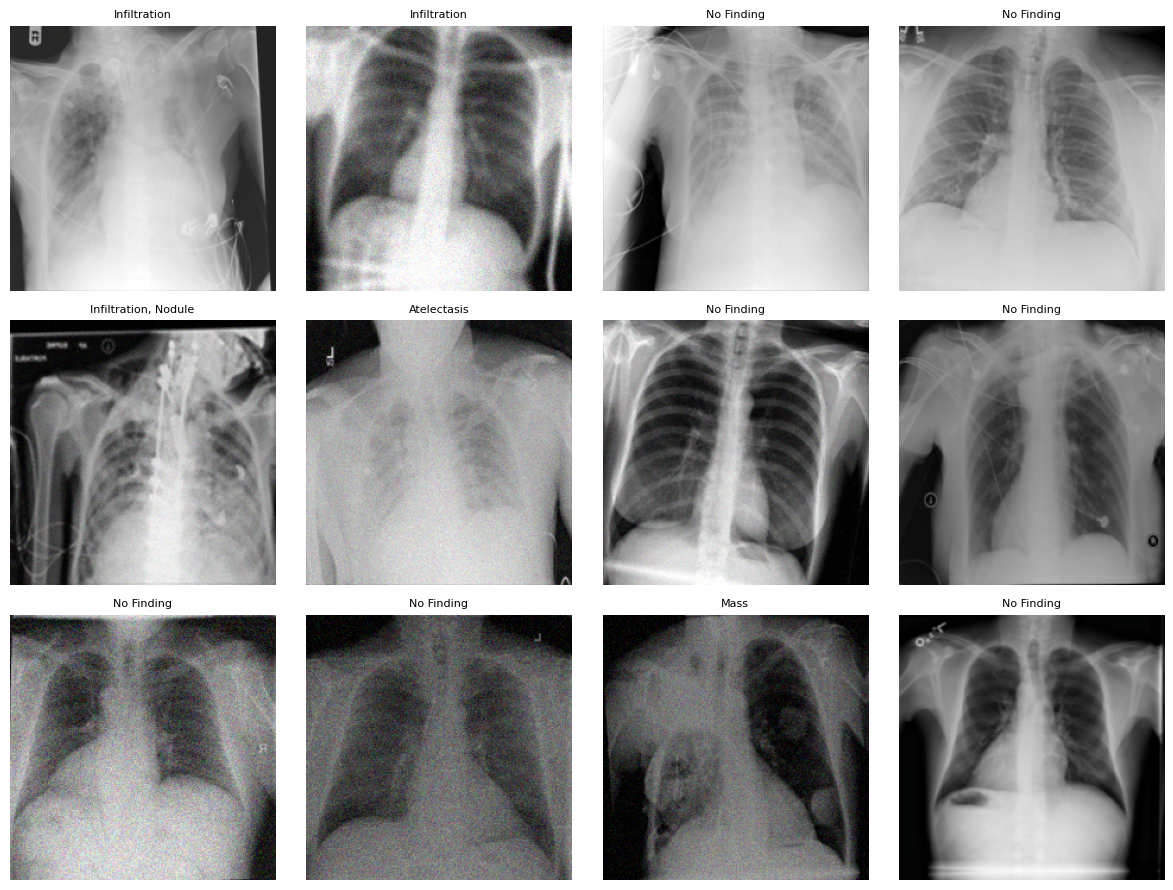

In [13]:
def visualize_train_samples(train_loader, class_names):
    images, labels = next(iter(train_loader))
    images = images.cpu()
    labels = labels.cpu()

    # 1. Define ImageNet stats as tensors reshaped for batch broadcasting (1, C, 1, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    # 2. Correctly reverse the ImageNet normalization
    images = images * std + mean

    # 3. Clamp values to [0, 1] to ensure matplotlib doesn't complain about floating point rounding errors
    images = torch.clamp(images, 0, 1)

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.flatten()

    for i in range(12):
        img = images[i]

        # Move channel dimension to the end for matplotlib (C, H, W) -> (H, W, C)
        img_np = img.permute(1, 2, 0).numpy()

        # Plot RGB
        axes[i].imshow(img_np)

        # Handle NIH multi-label parsing
        active = torch.where(labels[i] >= 0.5)[0]

        if active.numel() == 0:
            label_text = "No Finding"
        else:
            label_text = ", ".join([class_names[j] for j in active.tolist()])

        axes[i].set_title(label_text, fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the updated visualizer
visualize_train_samples(train_loader, class_names=DISEASES)

# Model Architecture

## Build the Main CheXNet Architecture
Constructing the full multi-label model by combining the DenseNet backbone with 14 parallel MLPHead instances. We need a shared feature extractor. By setting num_classes=0 in timm, we strip away the default ImageNet classification head.

In [14]:
class DenseCheX(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        # By passing num_classes=14, timm automatically drops the 1000-class 
        # ImageNet head and replaces it with a single nn.Linear(1024, 14) layer.
        self.model = timm.create_model(
            'densenet121', 
            pretrained=True, 
            num_classes=num_classes
        )

    def forward(self, x):
        # Outputs raw logits for the 14 classes to be used with BCEWithLogitsLoss
        return self.model(x)

## Instantiate and Prepare for Dual GPUs
Creating the model object, checking for available GPUs, and wrapping the model in nn.DataParallel

In [15]:
# Check hardware availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")
print(f"Number of GPUs available: {torch.cuda.device_count()}")

# Instantiate the model
model = DenseCheX(num_classes=len(DISEASES))

# Wrap model for multi-GPU training if more than 1 GPU is available
if torch.cuda.device_count() > 1:
    print("Dual GPUs detected! Wrapping model in nn.DataParallel...")
    model = nn.DataParallel(model)

# Move the model to the GPUs
model = model.to(device)

print("Model successfully instantiated and moved to device.")

Using compute device: cuda
Number of GPUs available: 2


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Dual GPUs detected! Wrapping model in nn.DataParallel...
Model successfully instantiated and moved to device.


## Test Model

In [16]:
# 1. Grab a single batch of data
sample_images, sample_labels = next(iter(train_loader))

# 2. Move the data to the correct device (GPUs)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"Input images shape: {sample_images.shape}")

# 3. Put the model in evaluation mode for the test
model.eval()

# 4. Perform a forward pass (no gradients needed)
with torch.no_grad():
    outputs = model(sample_images)

# 5. Verify the output
print(f"Model output shape: {outputs.shape}")
print(f"Expected output shape: torch.Size([{sample_images.shape[0]}, {len(DISEASES)}])")

# 6. Strict assertion to ensure shapes match
assert outputs.shape == (sample_images.shape[0], len(DISEASES)), "Error: Output shape mismatch!"
print("Sanity check passed successfully! The model correctly processed the batch.")

Input images shape: torch.Size([128, 3, 224, 224])
Model output shape: torch.Size([128, 14])
Expected output shape: torch.Size([128, 14])
Sanity check passed successfully! The model correctly processed the batch.


# Training & Validation Pipeline

## Define the Loss Function and Optimizer
Since this is a multi-label classification problem (a patient can have multiple diseases simultaneously), we treat each of the 14 outputs as an independent binary classification task.

In [17]:
# Binary Cross-Entropy Loss
criterion = torch.nn.BCEWithLogitsLoss()

# The peak learning rate from the paper
LEARNING_RATE = 1e-4
EPOCHS = 20
WARMUP_EPOCHS = 3 # Standard warmup duration

# AdamW with weight decay for regularization
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)

print("Optimizer configured with weight decay.")

Optimizer configured with weight decay.


## Sequential Learning Rate

In [18]:
# Phase 1: Warmup
# Starts the LR at 1% of the base learning rate and ramps up to 100% over WARMUP_EPOCHS
warmup_scheduler = LinearLR(
    optimizer, 
    start_factor=0.01, 
    end_factor=1.0, 
    total_iters=WARMUP_EPOCHS
)

# Phase 2: Cosine Decay
# Decays the LR from the base rate down to a minimum of 1e-6 over the remaining epochs
cosine_scheduler = CosineAnnealingLR(
    optimizer, 
    T_max=(EPOCHS - WARMUP_EPOCHS), 
    eta_min=1e-6
)

# Stitch them together
scheduler = SequentialLR(
    optimizer, 
    schedulers=[warmup_scheduler, cosine_scheduler], 
    milestones=[WARMUP_EPOCHS]
)

print(f"Built-in PyTorch SequentialLR configured for {EPOCHS} epochs.")

Built-in PyTorch SequentialLR configured for 20 epochs.


## Define the Evaluation Metric (AUROC)
Creating a helper function to calculate the Area Under the ROC Curve using scikit-learn.

In [19]:
def calculate_auroc(y_true, y_pred):
    """
    Calculates the Macro-Averaged AUROC score.
    
    Args:
        y_true (np.ndarray): Ground truth binary labels, shape (N, 14).
        y_pred (np.ndarray): Predicted probabilities (after sigmoid), shape (N, 14).
        
    Returns:
        float: The mean AUROC score across all 14 pathology classes.
    """
    # Suppress warnings in case a specific batch or subset lacks positive samples 
    # for a rare disease (though we compute this over the full validation set)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Calculate the macro-averaged AUROC
        # 'macro' calculates metrics for each label, and finds their unweighted mean.
        # This does not take label imbalance into account, giving equal weight to each disease.
        auc_score = roc_auc_score(y_true, y_pred, average='macro')
        
    return auc_score

## Define Comprehensive Clinical Metrics
While AUROC gives us the overall discriminatory power of the model across all thresholds, threshold-dependent metrics give us a snapshot of clinical utility at a specific decision boundary. We use zero_division=0 to prevent the training loop from crashing if a batch happens to lack positive predictions for a rare disease.

In [20]:
def calculate_comprehensive_metrics(y_true, y_pred_probs, threshold=0.5):
    """
    Calculates threshold-dependent metrics for multi-label classification.
    Note: Recall is mathematically identical to Sensitivity.
    
    Args:
        y_true (np.ndarray): Ground truth binary labels, shape (N, 14).
        y_pred_probs (np.ndarray): Predicted probabilities (after sigmoid), shape (N, 14).
        threshold (float): The probability threshold to convert logits to binary predictions.
        
    Returns:
        dict: A dictionary containing macro-averaged metrics.
    """
    # Convert probabilities to binary predictions (0 or 1) based on the threshold
    y_pred_binary = (y_pred_probs >= threshold).astype(int)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Calculate standard metrics (Macro-averaged across all 14 classes)
        # Recall is the same as Sensitivity in this context
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred_binary), # Exact match accuracy (strict in multi-label)
            'f1_macro': f1_score(y_true, y_pred_binary, average='macro', zero_division=0),
            'precision_macro': precision_score(y_true, y_pred_binary, average='macro', zero_division=0),
            'sensitivity_macro': recall_score(y_true, y_pred_binary, average='macro', zero_division=0) 
        }
        
        # Calculate Specificity (True Negative Rate) for each class, then macro-average
        specificities = []
        for i in range(y_true.shape[1]):
            # ravel() unwraps the confusion matrix into TN, FP, FN, TP
            tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred_binary[:, i], labels=[0, 1]).ravel()
            
            # Specificity = TN / (TN + FP)
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            specificities.append(specificity)
            
        metrics['specificity_macro'] = np.mean(specificities)
        
    return metrics

# The Training Loop & Checkpointing

## Define the Training Epoch Function
Modularizing the training logic keeps the main loop clean. This function handles moving data to your dual GPUs, zeroing gradients, performing the forward and backward passes, and updating the model weights.

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    """
    model.train()
    running_loss = 0.0
    
    # tqdm provides a nice progress bar in Kaggle notebooks
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        # Update progress bar with the current batch loss
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


## Define the Validation Epoch Function
We need to track the model's generalization and prevent overfitting. We accumulate all the predictions and true labels across all validation batches so we can pass them to our comprehensive scikit-learn metric functions at the end of the epoch. We apply the Sigmoid activation here to convert the raw logits into probabilities $[0, 1]$ before passing them to the AUROC function.

In [22]:
import numpy as np

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    
    progress_bar = tqdm(dataloader, desc="Validating", leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            
            probabilities = torch.sigmoid(outputs)
            all_preds.append(probabilities.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds, all_labels = np.vstack(all_preds), np.vstack(all_labels)
    
    # --- NEW: Calculate Per-Class AUCs ---
    # average=None returns an array of AUCs for each class
    per_class_aucs = roc_auc_score(all_labels, all_preds, average=None) 
    
    # Calculate the mean AUC across all classes for standard logging
    epoch_auroc = np.mean(per_class_aucs)
    
    # Keep your comprehensive metrics
    comp_metrics = calculate_comprehensive_metrics(all_labels, all_preds, threshold=0.5)
    
    # Return the per_class_aucs as well
    return epoch_loss, epoch_auroc, per_class_aucs, comp_metrics

## Execute the Main Loop and Save the Best Model
This is the execution cell. The SwinCheX authors found that the model usually peaks early and then begins to overfit, leading to a decline in AUC. By tracking the best_val_auroc and using torch.save, we ensure that even if the model overfits in later epochs, we retain the optimal weights

In [23]:
# 1. Initialize W&B Run
run = wandb.init(
    project="nih-chestx-ray-classification",
    config={
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "loss_function": "BCEWithLogitLoss",
        "augmentation": "CLAHE+Geometric+Intensity",
        "model_arch": "DenseCheX",
        "dynamic_oversampling": True # Good to log this!
    }
)
config = wandb.config

best_val_auroc = 0.0
model_save_path = 'best_model.pth'

# --- NEW: Keep a pristine copy of your original training data ---
base_train_df = train_df.copy()

print(f"Starting training for {config.epochs} epochs...")

for epoch in range(config.epochs):
    print(f"\nEpoch {epoch+1}/{config.epochs}")
    print(f"Current training dataset size: {len(train_loader.dataset)}")
    
    # 1. Train & Validate (Note the new unpack for per_class_aucs)
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    val_loss, val_auroc, per_class_aucs, comp_metrics = validate_one_epoch(model, val_loader, criterion, device)
    
    # 2. Log Epoch Metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "val/loss": val_loss,
        "val/auroc": val_auroc,
        "val/accuracy": comp_metrics['accuracy'],
        "val/f1_macro": comp_metrics['f1_macro'],
        "lr": optimizer.param_groups[0]['lr']
    })
    
    # 3. Checkpointing
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        wandb.run.summary["best_val_auroc"] = best_val_auroc
        save_obj = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
        torch.save(save_obj, model_save_path)
        wandb.save(model_save_path)

    # ---------------------------------------------------------
    # 4. --- NEW: DYNAMIC OVERSAMPLING LOGIC ---
    # ---------------------------------------------------------
    
    # Find classes that performed worse than the average this epoch
    average_auc = np.mean(per_class_aucs)
    underperforming_classes = [
        DISEASES[i] for i, auc in enumerate(per_class_aucs) if auc < average_auc
    ]
    
    print(f"Average AUC: {average_auc:.4f}. Oversampling: {underperforming_classes}")
    
    if underperforming_classes:
        # Create a boolean mask: True if a row has a '1' in ANY of the underperforming classes
        # Assuming your labels in the dataframe are 1s and 0s
        mask = base_train_df[underperforming_classes].sum(axis=1) > 0
        
        # Extract those rows
        rows_to_duplicate = base_train_df[mask]
        
        # Optional: You can sample a fraction of them so you don't double the dataset size instantly
        # rows_to_duplicate = rows_to_duplicate.sample(frac=0.5, random_state=42)
        
        # Append them to the base dataframe
        new_train_df = pd.concat([base_train_df, rows_to_duplicate]).reset_index(drop=True)
    else:
        # Fallback just in case
        new_train_df = base_train_df.copy()

    # Re-instantiate the Dataset and DataLoader for the NEXT epoch
    train_dataset = ChestXrayDataset(new_train_df, transform=train_transform)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,      # Shuffle the new dataset
        num_workers=4,
        pin_memory=True
    )

# 5. Finish the run
wandb.finish()

wandb: WARNING Changes to your `wandb` environment variables will be ignored because your `wandb` session has already started. For more information on how to modify your settings with `wandb.init()` arguments, please refer to https://wandb.me/wandb-init.
wandb: setting up run rf8c8ucb
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260303_220143-rf8c8ucb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run desert-pond-37
wandb: ⭐️ View project at https://wandb.ai/nifdiguliyev/nih-chestx-ray-classification
wandb: 🚀 View run at https://wandb.ai/nifdiguliyev/nih-chestx-ray-classification/runs/rf8c8ucb


Starting training for 20 epochs...

Epoch 1/20
Current training dataset size: 72061


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Validating:   0%|          | 0/139 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

Training:   0%|          | 0/755 [00:00<?, ?it/s]

Validating:   0%|          | 0/139 [00:00<?, ?it/s]

wandb: updating run metadata


Average AUC: 0.8077. Oversampling: ['Atelectasis', 'Consolidation', 'Fibrosis', 'Infiltration', 'Nodule', 'Pleural_Thickening', 'Pneumonia']


wandb: 
wandb: Run history:
wandb:        epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:           lr ▃▆███▇▇▇▆▅▅▄▄▃▂▂▂▁▁▁
wandb:   train/loss █▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
wandb: val/accuracy ▁██████████████▇█▇▇▇
wandb:    val/auroc ▁▅▆▇▇███████████████
wandb: val/f1_macro ▃▁▃▃▅▅▆▇▆▇▇█████████
wandb:     val/loss █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb: best_val_auroc 0.82167
wandb:          epoch 20
wandb:             lr 0.0
wandb:     train/loss 0.1396
wandb:   val/accuracy 0.50521
wandb:      val/auroc 0.80775
wandb:   val/f1_macro 0.20051
wandb:       val/loss 0.16161
wandb: 
wandb: 🚀 View run desert-pond-37 at: https://wandb.ai/nifdiguliyev/nih-chestx-ray-classification/runs/rf8c8ucb
wandb: ⭐️ View project at: https://wandb.ai/nifdiguliyev/nih-chestx-ray-classification
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260303_220143-rf8c8ucb/logs


# Inference and Testing

## Load the best model

In [24]:
print("Loading the best model for testing...")

# 1. Instantiate the base model (using Swin-Base as we configured)
test_model = DenseCheX(num_classes=len(DISEASES))

# 2. Load the saved weights
# model_save_path = '/kaggle/working/best_swinchex_model.pth'
model_save_path = '/kaggle/working/best_model.pth'

if os.path.exists(model_save_path):
    # We saved model.module.state_dict() during training, so we load directly into the base model
    test_model.load_state_dict(torch.load(model_save_path))
    print("Successfully loaded optimal weights from checkpoint.")
else:
    print(f"Error: Could not find checkpoint at {model_save_path}")

# 3. Move to device and wrap in DataParallel for the Dual T4s
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    test_model = nn.DataParallel(test_model)

test_model = test_model.to(device)
test_model.eval() # CRITICAL: Set to evaluation mode to disable dropout/batchnorm updates

Loading the best model for testing...
Successfully loaded optimal weights from checkpoint.


DataParallel(
  (module): DenseCheX(
    (model): DenseNet(
      (features): Sequential(
        (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (denseblock1): DenseBlock(
          (denselayer1): DenseLayer(
            (norm1): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): ReLU(inplace=True)
            )
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNormAct2d(
              128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): ReLU(

## Perform inference on test

In [25]:
print("Running inference on the unseen Test Set...")

all_test_preds = []
all_test_labels = []

# Create a progress bar
test_progress = tqdm(test_loader, desc="Testing", leave=False)

with torch.no_grad():
    for images, labels in test_progress:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = test_model(images)
        
        # Convert to probabilities
        probabilities = torch.sigmoid(outputs)
        
        # Move to CPU and store
        all_test_preds.append(probabilities.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

# Stack the batches into full numpy arrays
test_preds_np = np.vstack(all_test_preds)
test_labels_np = np.vstack(all_test_labels)

print(f"Inference complete. Total test images processed: {test_labels_np.shape[0]}")

Running inference on the unseen Test Set...


Testing:   0%|          | 0/175 [00:00<?, ?it/s]

Inference complete. Total test images processed: 22294


## Calculate performance for each class

In [26]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_curve, f1_score
import numpy as np
import pandas as pd
import warnings

print("Calculating detailed F1 breakdown...\n")

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i, disease in enumerate(DISEASES):
        true_labels = test_labels_np[:, i]
        pred_probs = test_preds_np[:, i]

        # 1. Calculate AUROC
        try:
            auc = roc_auc_score(true_labels, pred_probs)
        except ValueError:
            auc = np.nan

        # 3. Apply the threshold and calculate the FULL breakdown
        pred_binary = (pred_probs >= 0.5).astype(int)

        # Calculate the Negative F1 and Macro F1 explicitly
        # Note: zero_division=0 prevents warnings if a class is entirely missed
        macro_f1 = f1_score(true_labels, pred_binary, average='macro', zero_division=0)

        acc = accuracy_score(true_labels, pred_binary)

        results.append({
            'Pathology': disease,
            'F1': macro_f1,
            'AUROC': auc
        })

# Create DataFrame
results_df = pd.DataFrame(results)

# Append Means
mean_row = pd.DataFrame([{
    'Pathology': 'MEAN',
    'F1': results_df['F1'].mean(),
    'AUROC': results_df['AUROC'].mean()
}])
results_df = pd.concat([results_df, mean_row], ignore_index=True)

# Format for clean output
for col in ['F1', 'AUROC']:
    results_df[col] = results_df[col].map('{:.3f}'.format)

display(results_df)

Calculating detailed F1 breakdown...



,Pathology,F1,AUROC
0,Atelectasis,0.628,0.801
1,Cardiomegaly,0.610,0.901
2,Consolidation,0.511,0.812
3,Edema,0.538,0.880
4,Effusion,0.711,0.875
5,Emphysema,0.688,0.910
6,Fibrosis,0.517,0.797
7,Hernia,0.499,0.890
8,Infiltration,0.593,0.701
9,Mass,0.636,0.817
